# 03f — E3a Adapted Self-Blended Images Training

**Experiment:** E3a — EfficientNet-B0 trained with the adapted dynamic SBI implementation  
**Purpose:** Test whether generating synthetic self-blended faces during training improves generalisation beyond the supervised E2.2 baseline.

This notebook contains SBI generation, training-data loading, training, and validation only. It does **not** evaluate genuine FaceForensics++ test deepfakes. Internal evaluation belongs in `04f_E3a_FFPP_Evaluation.ipynb`.

The implementation and training cells were extracted directly from the master notebook. The synthetic SBI images remain dynamic and are not saved permanently.

## Experimental design

- **Research question:** Does replacing supervised FF++ fake training examples with dynamically generated adapted SBI pairs improve performance on genuine unseen manipulations?
- **Primary comparator:** E2.2 face-crop EfficientNet-B0
- **Experimental intervention:** Adapted dynamic self-blended-image training using only real FF++ source frames
- **Training source:** Real FaceForensics++ frames and their RetinaFace/landmark metadata in `sbi_dataset/train`
- **Validation source:** Real validation frames converted into deterministic real/SBI pairs
- **Model:** ImageNet-pretrained EfficientNet-B0, fully fine-tuned
- **SBI labels:** Real = 0, synthetic SBI fake = 1
- **Batch setting:** Eight source frames, expanded into 16 real/SBI model inputs
- **Optimizer:** Adam, learning rate 0.0001, weight decay 0.0001
- **Epochs:** 10
- **Checkpoint rule:** Save the best deterministic SBI-validation-accuracy checkpoint
- **Checkpoint:** `saved_models/efficientnet_b0_sbi_best.pth`

The SBI validation accuracy measures discrimination between real and synthetic SBI pairs; it is **not directly comparable** with E2.2 validation accuracy on genuine FF++ real/fake samples. The fair comparison is made later in `04f_E3a_FFPP_Evaluation.ipynb`, using genuine held-out FF++ videos and no SBI generation during testing.

This is the adapted SBI experiment, not the later official SBI implementation used by E3b.


## 1. Safety control

Training is disabled by default. Set `RUN_TRAINING = True` to train E3a. If its checkpoint already exists, training stops unless `ALLOW_CHECKPOINT_OVERWRITE = True` is also set. Synthetic fake images remain in memory and are never saved to the dataset.


In [1]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

CHECKPOINT_NAME = "efficientnet_b0_sbi_best.pth"
RESULTS_NAME = "efficientnet_b0_sbi_training_results.json"
LOSS_PLOT_NAME = "efficientnet_b0_sbi_loss.png"
ACCURACY_PLOT_NAME = "efficientnet_b0_sbi_accuracy.png"

print("E3a training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("E3a checkpoint:", CHECKPOINT_NAME)


E3a training enabled: True
Allow checkpoint overwrite: False
E3a checkpoint: efficientnet_b0_sbi_best.pth


## 2. Mount Drive and verify required prepared data

This notebook mounts Drive itself. It expects the directories created by `00_Project_Setup.ipynb` and the triplets created by `02b_SBI_Preprocessing.ipynb`. It does not rebuild or delete them.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path
import torch

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
SBI_BASE = BASE_PATH / "sbi_dataset"
SPLIT_MANIFEST_PATH = BASE_PATH / "ffpp_video_split_manifest.json"
CHECKPOINT_PATH = BASE_PATH / "saved_models" / CHECKPOINT_NAME
RESULTS_PATH = BASE_PATH / "results" / RESULTS_NAME
LOSS_PLOT_PATH = BASE_PATH / "plots" / LOSS_PLOT_NAME
ACCURACY_PLOT_PATH = BASE_PATH / "plots" / ACCURACY_PLOT_NAME

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("SBI input:", SBI_BASE)
print("Checkpoint:", CHECKPOINT_PATH)

required_directories = [
    SBI_BASE / split / item / "real"
    for split in ("train", "val")
    for item in ("frames", "retina", "landmarks")
]
for required_directory in required_directories:
    assert required_directory.is_dir(), f"Required SBI directory not found: {required_directory}"
assert SPLIT_MANIFEST_PATH.is_file(), f"Split manifest not found: {SPLIT_MANIFEST_PATH}"

if RUN_TRAINING and CHECKPOINT_PATH.exists() and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"Checkpoint already exists: {CHECKPOINT_PATH}. "
        "Set ALLOW_CHECKPOINT_OVERWRITE = True only if replacement is intentional."
    )


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
SBI input: /content/drive/MyDrive/deepfake_project/sbi_dataset
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_sbi_best.pth


## 3. Audit SBI triplets and source-video separation

Every usable source frame must have a frame file, RetinaFace array, and landmark array. The audit also verifies that the real training and validation source-video identities exactly match the saved FF++ manifest and do not overlap.


In [3]:
import json
import pandas as pd

def audit_sbi_split(split):
    frames_root = SBI_BASE / split / "frames" / "real"
    retina_root = SBI_BASE / split / "retina" / "real"
    landmarks_root = SBI_BASE / split / "landmarks" / "real"
    frame_files = sorted(frames_root.glob("*/*.png"))
    complete = []
    for frame_path in frame_files:
        video_name = frame_path.parent.name
        stem = frame_path.stem
        if (retina_root / video_name / f"{stem}.npy").is_file() and (landmarks_root / video_name / f"{stem}.npy").is_file():
            complete.append(frame_path)
    return complete, {path.parent.name for path in complete}

with SPLIT_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    split_manifest = json.load(handle)

audit_rows = []
actual_video_ids = {}
expected_counts = {"train": 1342, "val": 290}
expected_video_counts = {"train": 140, "val": 30}
for split in ("train", "val"):
    complete, video_ids = audit_sbi_split(split)
    expected_ids = {Path(name).stem for name in split_manifest["classes"]["real"][split]}
    assert video_ids == expected_ids, f"{split} SBI video ids do not match the split manifest."
    assert len(complete) == expected_counts[split], f"Unexpected {split} complete-triplet count: {len(complete)}"
    assert len(video_ids) == expected_video_counts[split], f"Unexpected {split} source-video count: {len(video_ids)}"
    actual_video_ids[split] = video_ids
    audit_rows.append({"split": split, "complete_triplets": len(complete), "source_videos": len(video_ids)})

overlap = actual_video_ids["train"] & actual_video_ids["val"]
assert not overlap, f"Train/validation source-video overlap detected: {sorted(overlap)[:5]}"
display(pd.DataFrame(audit_rows))
print("PASS: SBI triplets match the clean source-video manifest with no train/validation overlap.")


,split,complete_triplets,source_videos
0,train,1342,140
1,val,290,30


PASS: SBI triplets match the clean source-video manifest with no train/validation overlap.


## 4. Optional visual verification of the adapted SBI generator

Selected video: 15__walking_and_outside_surprised
Selected frame: 15__walking_and_outside_surprised_frame_7.png
Full frame shape: (1080, 1920, 3)
Retina shape: (2, 7, 2)
Landmark shape: (1, 81, 2)


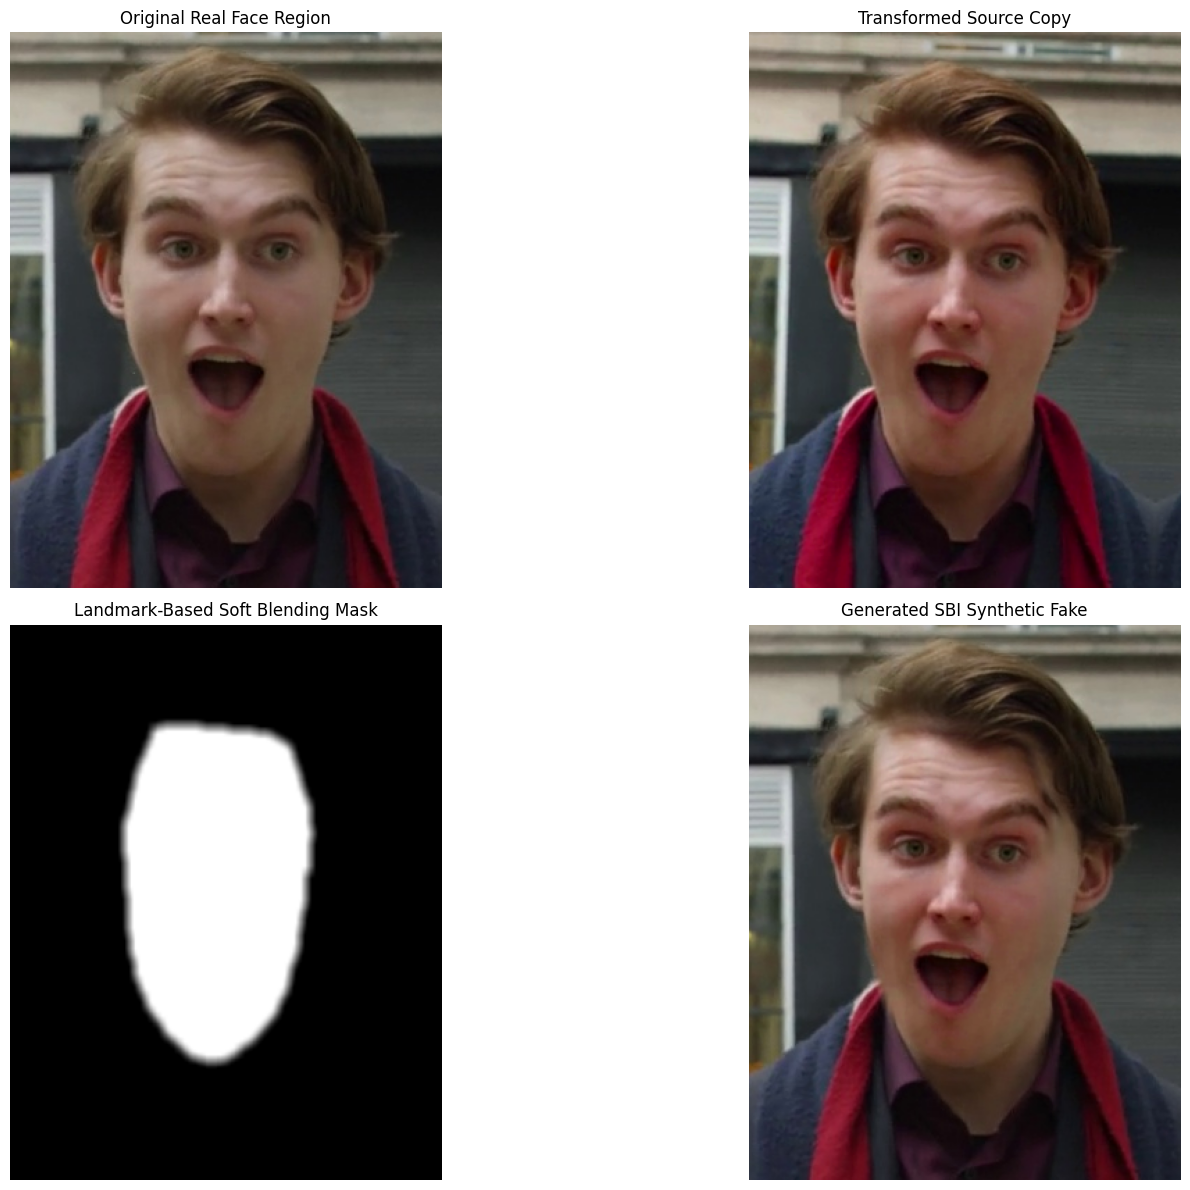


Visual verification guidance:
- The fake should still look like the same person.
- The manipulated facial region should be subtle.
- There should not be an obvious rectangular boundary.
- The mask should follow the facial contour.
- Small colour, scale, alignment or texture differences are expected.


In [4]:
# ============================================================
# Visual verification of Self-Blended Image generation
#
# This cell:
# 1. Selects one preprocessed REAL SBI frame.
# 2. Loads its RetinaFace box and 81 facial landmarks.
# 3. Crops the main facial region.
# 4. Creates a landmark-based facial mask.
# 5. Modifies and geometrically deforms a copy of the face.
# 6. Blends the modified copy back into the original.
# 7. Displays the real image, source, mask and SBI fake.
#
# Safety:
# - Does not delete anything.
# - Does not overwrite the SBI dataset.
# - Does not save synthetic fake images permanently.
# ============================================================

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/deepfake_project"
sbi_base = os.path.join(base_path, "sbi_dataset")

SPLIT_NAME = "train"
CLASS_NAME = "real"
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ------------------------------------------------------------
# Collect valid real samples
# ------------------------------------------------------------

frames_root = os.path.join(
    sbi_base,
    SPLIT_NAME,
    "frames",
    CLASS_NAME
)

retina_root = os.path.join(
    sbi_base,
    SPLIT_NAME,
    "retina",
    CLASS_NAME
)

landmarks_root = os.path.join(
    sbi_base,
    SPLIT_NAME,
    "landmarks",
    CLASS_NAME
)

valid_samples = []

for video_name in os.listdir(frames_root):

    frame_folder = os.path.join(frames_root, video_name)

    if not os.path.isdir(frame_folder):
        continue

    for frame_file in os.listdir(frame_folder):

        if not frame_file.lower().endswith(".png"):
            continue

        frame_stem = os.path.splitext(frame_file)[0]

        frame_path = os.path.join(
            frame_folder,
            frame_file
        )

        retina_path = os.path.join(
            retina_root,
            video_name,
            frame_stem + ".npy"
        )

        landmark_path = os.path.join(
            landmarks_root,
            video_name,
            frame_stem + ".npy"
        )

        if (
            os.path.exists(frame_path)
            and os.path.exists(retina_path)
            and os.path.exists(landmark_path)
        ):
            valid_samples.append({
                "video": video_name,
                "frame": frame_file,
                "frame_path": frame_path,
                "retina_path": retina_path,
                "landmark_path": landmark_path
            })

if not valid_samples:
    raise RuntimeError("No valid real SBI samples were found.")

sample = random.choice(valid_samples)

print("Selected video:", sample["video"])
print("Selected frame:", sample["frame"])


# ------------------------------------------------------------
# Load frame and metadata
# ------------------------------------------------------------

frame_bgr = cv2.imread(sample["frame_path"])

if frame_bgr is None:
    raise RuntimeError("Could not load the selected frame.")

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)

retina_array = np.load(sample["retina_path"])
landmark_array = np.load(sample["landmark_path"])

print("Full frame shape:", frame_rgb.shape)
print("Retina shape:", retina_array.shape)
print("Landmark shape:", landmark_array.shape)

# The largest face was saved first during preprocessing.
retina_face = retina_array[0]
landmarks = landmark_array[0].astype(np.float32)


# ------------------------------------------------------------
# Crop around the main face with margin
# ------------------------------------------------------------

x1, y1 = retina_face[0]
x2, y2 = retina_face[1]

x1, y1, x2, y2 = map(
    int,
    [x1, y1, x2, y2]
)

frame_h, frame_w = frame_rgb.shape[:2]

face_width = x2 - x1
face_height = y2 - y1

margin = int(
    0.35 * max(face_width, face_height)
)

crop_x1 = max(x1 - margin, 0)
crop_y1 = max(y1 - margin, 0)
crop_x2 = min(x2 + margin, frame_w)
crop_y2 = min(y2 + margin, frame_h)

real_crop = frame_rgb[
    crop_y1:crop_y2,
    crop_x1:crop_x2
].copy()

if real_crop.size == 0:
    raise RuntimeError("The selected facial crop is empty.")

# Convert full-frame landmark coordinates to crop coordinates.
crop_landmarks = landmarks.copy()
crop_landmarks[:, 0] -= crop_x1
crop_landmarks[:, 1] -= crop_y1

crop_h, crop_w = real_crop.shape[:2]


# ------------------------------------------------------------
# Create landmark-based face mask
# ------------------------------------------------------------

mask = np.zeros(
    (crop_h, crop_w),
    dtype=np.float32
)

valid_landmarks = crop_landmarks.copy()

valid_landmarks[:, 0] = np.clip(
    valid_landmarks[:, 0],
    0,
    crop_w - 1
)

valid_landmarks[:, 1] = np.clip(
    valid_landmarks[:, 1],
    0,
    crop_h - 1
)

face_hull = cv2.convexHull(
    valid_landmarks.astype(np.int32)
)

cv2.fillConvexPoly(
    mask,
    face_hull,
    1.0
)


# ------------------------------------------------------------
# Source appearance transformation
#
# SBI creates source and target from the same real image.
# One copy receives colour/quality transformations.
# ------------------------------------------------------------

def modify_source_appearance(image_rgb):
    """
    Apply random colour and image-quality changes to the source copy.
    """

    source = image_rgb.copy()

    # Convert to HSV for hue, saturation and brightness modification.
    hsv = cv2.cvtColor(
        source,
        cv2.COLOR_RGB2HSV
    ).astype(np.float32)

    hue_shift = np.random.uniform(-8, 8)
    saturation_scale = np.random.uniform(0.80, 1.20)
    value_scale = np.random.uniform(0.85, 1.15)

    hsv[:, :, 0] = (
        hsv[:, :, 0] + hue_shift
    ) % 180

    hsv[:, :, 1] = np.clip(
        hsv[:, :, 1] * saturation_scale,
        0,
        255
    )

    hsv[:, :, 2] = np.clip(
        hsv[:, :, 2] * value_scale,
        0,
        255
    )

    source = cv2.cvtColor(
        hsv.astype(np.uint8),
        cv2.COLOR_HSV2RGB
    )

    # Apply a slight blur or sharpening variation.
    if np.random.rand() < 0.5:
        source = cv2.GaussianBlur(
            source,
            (3, 3),
            0
        )
    else:
        blurred = cv2.GaussianBlur(
            source,
            (0, 0),
            1.0
        )

        source = cv2.addWeighted(
            source,
            1.3,
            blurred,
            -0.3,
            0
        )

    return source


source_image = modify_source_appearance(
    real_crop
)


# ------------------------------------------------------------
# Apply a small random affine transformation to source and mask
# ------------------------------------------------------------

angle = np.random.uniform(-3.0, 3.0)
scale = np.random.uniform(0.95, 1.05)

translation_x = np.random.uniform(
    -0.03,
    0.03
) * crop_w

translation_y = np.random.uniform(
    -0.015,
    0.015
) * crop_h

centre = (
    crop_w / 2,
    crop_h / 2
)

affine_matrix = cv2.getRotationMatrix2D(
    centre,
    angle,
    scale
)

affine_matrix[0, 2] += translation_x
affine_matrix[1, 2] += translation_y

source_warped = cv2.warpAffine(
    source_image,
    affine_matrix,
    (crop_w, crop_h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_REFLECT
)

mask_warped = cv2.warpAffine(
    mask,
    affine_matrix,
    (crop_w, crop_h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)


# ------------------------------------------------------------
# Dynamic SBI blending mask
#
# The official implementation:
# - applies Gaussian smoothing,
# - selects a random blending strength,
# - blends the modified source with the original target.
# ------------------------------------------------------------

def create_dynamic_blend_mask(input_mask):
    """
    Create a soft, irregular blending mask inspired by the official
    SBI dynamic_blend and get_blend_mask implementation.
    """

    working_mask = input_mask.astype(np.float32)

    # Resize temporarily, as done in the official implementation.
    temporary_height = np.random.randint(192, 257)
    temporary_width = np.random.randint(192, 257)

    resized_mask = cv2.resize(
        working_mask,
        (temporary_width, temporary_height),
        interpolation=cv2.INTER_LINEAR
    )

    kernel_1 = random.randrange(5, 26, 2)
    kernel_2 = random.randrange(5, 26, 2)

    resized_mask = cv2.GaussianBlur(
        resized_mask,
        (kernel_1, kernel_1),
        0
    )

    if resized_mask.max() > 0:
        resized_mask = (
            resized_mask / resized_mask.max()
        )

    # Recreate the hard central region before softening edges.
    resized_mask[
        resized_mask < 1.0
    ] = 0.0

    sigma = np.random.randint(5, 46)

    resized_mask = cv2.GaussianBlur(
        resized_mask,
        (kernel_2, kernel_2),
        sigma
    )

    if resized_mask.max() > 0:
        resized_mask = (
            resized_mask / resized_mask.max()
        )

    soft_mask = cv2.resize(
        resized_mask,
        (crop_w, crop_h),
        interpolation=cv2.INTER_LINEAR
    )

    blend_strengths = [
        0.25,
        0.50,
        0.75,
        1.00,
        1.00,
        1.00
    ]

    blend_strength = random.choice(
        blend_strengths
    )

    soft_mask = np.clip(
        soft_mask * blend_strength,
        0.0,
        1.0
    )

    return soft_mask


blend_mask = create_dynamic_blend_mask(
    mask_warped
)

blend_mask_3d = blend_mask[:, :, np.newaxis]


# ------------------------------------------------------------
# Produce synthetic self-blended fake
# ------------------------------------------------------------

synthetic_fake = (
    blend_mask_3d
    * source_warped.astype(np.float32)
    +
    (1.0 - blend_mask_3d)
    * real_crop.astype(np.float32)
)

synthetic_fake = np.clip(
    synthetic_fake,
    0,
    255
).astype(np.uint8)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.imshow(real_crop)
plt.title("Original Real Face Region")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(source_warped)
plt.title("Transformed Source Copy")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(blend_mask, cmap="gray")
plt.title("Landmark-Based Soft Blending Mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(synthetic_fake)
plt.title("Generated SBI Synthetic Fake")
plt.axis("off")

plt.tight_layout()
plt.show()

print()
print("Visual verification guidance:")
print("- The fake should still look like the same person.")
print("- The manipulated facial region should be subtle.")
print("- There should not be an obvious rectangular boundary.")
print("- The mask should follow the facial contour.")
print("- Small colour, scale, alignment or texture differences are expected.")

## 5. Adapted dynamic SBI dataset and data loaders

Dynamic SBI train source frames: 1342
Dynamic SBI val source frames: 290
Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]

Quality details for this batch:
Pair 1: {'reason': 'accepted', 'real_blur': np.float64(96.34118721302012), 'fake_blur': np.float64(89.24341698579563), 'mean_difference': 3.829340934753418, 'attempt': 1, 'profile_face': np.False_, 'profile_ratio': np.float32(0.9877831)}
Pair 2: {'reason': 'accepted', 'real_blur': np.float64(4.760723747054841), 'fake_blur': np.float64(3.8975419016563615), 'mean_difference': 1.34969961643219, 'attempt': 1, 'profile_face': np.False_, 'profile_ratio': np.float32(0.7623254)}
Pair 3: {'reason': 'accepted', 'real_blur': np.float64(196.2356587940413), 'fake_blur': np.float64(175.54074249380213), 'mean_difference': 4.159451484680176, 'attempt': 1, 'profile_face': np.False_, 'profile_ratio': np.float32(0.96601534)}
Pair 4: {'reason': 'accepted', 're

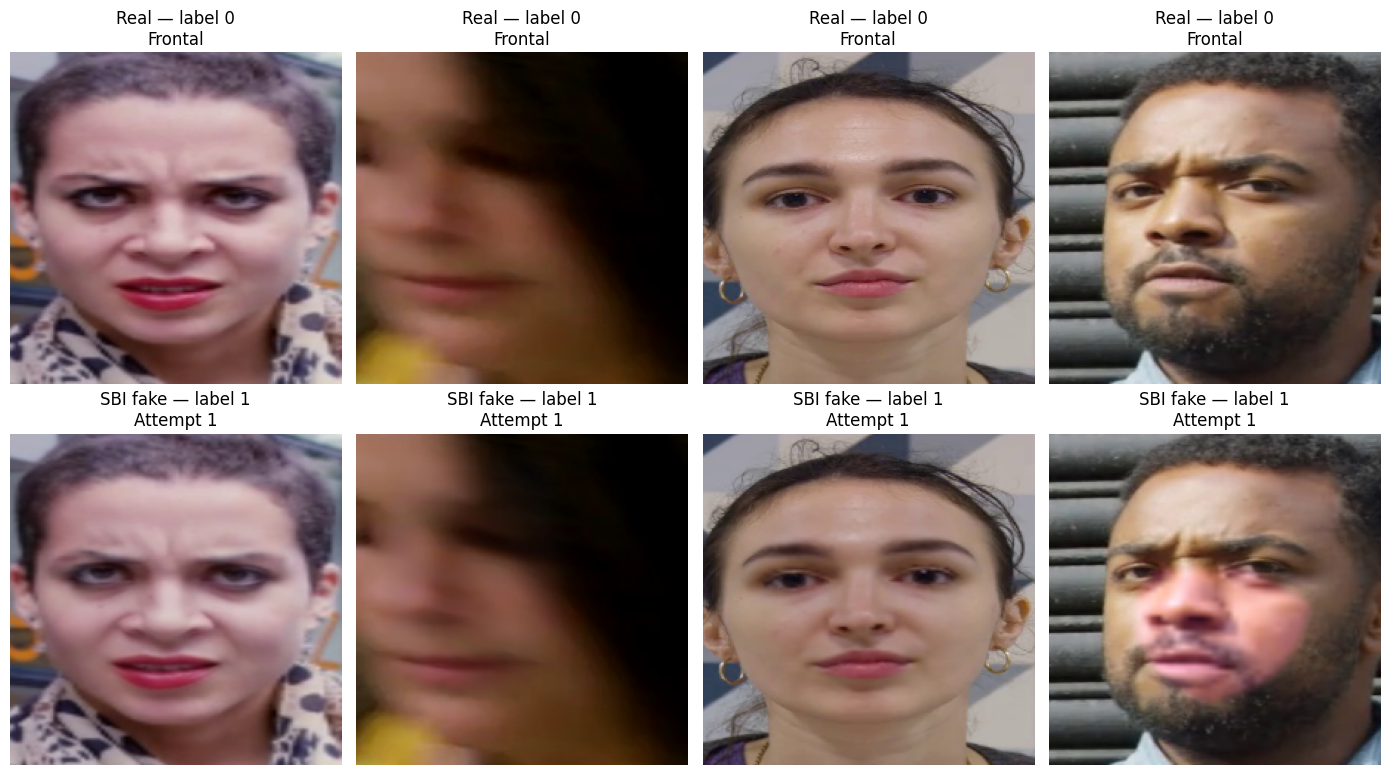


Expected output:
Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])

Visual acceptance criteria:
- Identity remains recognisable.
- No melted or severely stretched facial features.
- Mouth and eyes remain anatomically plausible.
- No obvious rectangular blending boundary.
- Mild colour, texture or alignment differences are expected.
- A small number of imperfect samples is acceptable.


In [5]:
# ============================================================
# E3: Dynamic Self-Blended Images (SBI) Dataset Loader
#
# Uses the existing files:
#   sbi_dataset/<split>/frames/real/
#   sbi_dataset/<split>/retina/real/
#   sbi_dataset/<split>/landmarks/real/
#
# Dynamically produces:
#   original real image  -> label 0
#   self-blended image   -> label 1
#
# Improvements in this version:
# - Conservative geometric deformation
# - Side-profile-aware augmentation
# - Blur detection
# - Excessive-distortion detection
# - Up to four regeneration attempts
#
# Safety:
# - Does not rebuild sbi_dataset
# - Does not delete anything
# - Does not save synthetic images to Drive
# ============================================================

import os
import cv2
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# General settings
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/deepfake_project"
sbi_base = os.path.join(base_path, "sbi_dataset")

IMAGE_SIZE = 224
RANDOM_SEED = 42

# Number of attempts to create an acceptable SBI fake
MAX_SBI_GENERATION_ATTEMPTS = 4

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ------------------------------------------------------------
# Bounding-box IoU
# Adapted from the official SBI implementation
# ------------------------------------------------------------

def iou_from_two_boxes(box_a, box_b):
    x_a = max(box_a[0], box_b[0])
    y_a = max(box_a[1], box_b[1])
    x_b = min(box_a[2], box_b[2])
    y_b = min(box_a[3], box_b[3])

    intersection = (
        max(0, x_b - x_a + 1)
        * max(0, y_b - y_a + 1)
    )

    area_a = (
        (box_a[2] - box_a[0] + 1)
        * (box_a[3] - box_a[1] + 1)
    )

    area_b = (
        (box_b[2] - box_b[0] + 1)
        * (box_b[3] - box_b[1] + 1)
    )

    denominator = area_a + area_b - intersection

    if denominator <= 0:
        return 0.0

    return intersection / float(denominator)


# ------------------------------------------------------------
# Face-cropping function
# Based on the official SBI crop_face() logic
# ------------------------------------------------------------

def crop_face(
    image,
    landmarks=None,
    bbox=None,
    margin=False,
    crop_by_bbox=True,
    phase="train",
    return_absolute_coordinates=False
):
    assert phase in ["train", "val", "test"]
    assert landmarks is not None or bbox is not None

    height, width = image.shape[:2]

    if crop_by_bbox:
        x0, y0 = bbox[0]
        x1, y1 = bbox[1]

        face_width = x1 - x0
        face_height = y1 - y0

        left_margin = face_width / 4
        right_margin = face_width / 4
        top_margin = face_height / 4
        bottom_margin = face_height / 4

    else:
        # The official SBI code uses the first 68 landmarks
        # to define the main facial region.
        x0 = landmarks[:68, 0].min()
        y0 = landmarks[:68, 1].min()
        x1 = landmarks[:68, 0].max()
        y1 = landmarks[:68, 1].max()

        face_width = x1 - x0
        face_height = y1 - y0

        left_margin = face_width / 8
        right_margin = face_width / 8
        top_margin = face_height / 2
        bottom_margin = face_height / 5

    if margin:
        left_margin *= 4
        right_margin *= 4
        top_margin *= 2
        bottom_margin *= 2

    elif phase == "train":
        left_margin *= np.random.uniform(0.2, 0.8)
        right_margin *= np.random.uniform(0.2, 0.8)
        top_margin *= np.random.uniform(0.2, 0.8)
        bottom_margin *= np.random.uniform(0.2, 0.8)

    else:
        left_margin *= 0.5
        right_margin *= 0.5
        top_margin *= 0.5
        bottom_margin *= 0.5

    new_y0 = max(0, int(y0 - top_margin))
    new_y1 = min(height, int(y1 + bottom_margin) + 1)
    new_x0 = max(0, int(x0 - left_margin))
    new_x1 = min(width, int(x1 + right_margin) + 1)

    cropped_image = image[
        new_y0:new_y1,
        new_x0:new_x1
    ]

    if cropped_image.size == 0:
        raise ValueError("Empty facial crop generated.")

    cropped_landmarks = None

    if landmarks is not None:
        cropped_landmarks = landmarks.copy()
        cropped_landmarks[:, 0] -= new_x0
        cropped_landmarks[:, 1] -= new_y0

    cropped_bbox = None

    if bbox is not None:
        cropped_bbox = bbox.copy()
        cropped_bbox[:, 0] -= new_x0
        cropped_bbox[:, 1] -= new_y0

    if return_absolute_coordinates:
        return (
            cropped_image,
            cropped_landmarks,
            cropped_bbox,
            new_y0,
            new_y1,
            new_x0,
            new_x1
        )

    return (
        cropped_image,
        cropped_landmarks,
        cropped_bbox
    )


# ------------------------------------------------------------
# Detect whether the selected face is strongly side-profiled
#
# RetinaFace metadata:
# index 0 = top-left bounding-box point
# index 1 = bottom-right bounding-box point
# index 2 = left eye
# index 3 = right eye
# index 4 = nose
# index 5 = left mouth corner
# index 6 = right mouth corner
# ------------------------------------------------------------

def is_side_profile(retina_points, threshold=0.55):
    """
    Estimate whether the face is side-profiled.

    For a frontal face, the nose is usually positioned reasonably
    evenly between the two eyes. For a profile face, the nose is
    much closer to one eye than the other.

    Returns:
        is_profile: bool
        symmetry_ratio: float
    """

    if retina_points.shape[0] < 5:
        return False, 1.0

    left_eye = retina_points[2].astype(np.float32)
    right_eye = retina_points[3].astype(np.float32)
    nose = retina_points[4].astype(np.float32)

    distance_left = np.linalg.norm(nose - left_eye)
    distance_right = np.linalg.norm(nose - right_eye)

    largest_distance = max(
        distance_left,
        distance_right,
        1e-6
    )

    smallest_distance = min(
        distance_left,
        distance_right
    )

    symmetry_ratio = smallest_distance / largest_distance

    return symmetry_ratio < threshold, symmetry_ratio


# ------------------------------------------------------------
# Source-image transformations
# ------------------------------------------------------------

def random_downscale(image, conservative=False):
    height, width = image.shape[:2]

    # For a side-profile image, avoid the stronger 4x downscale.
    ratio = 2 if conservative else random.choice([2, 4])

    small = cv2.resize(
        image,
        (
            max(1, width // ratio),
            max(1, height // ratio)
        ),
        interpolation=cv2.INTER_NEAREST
    )

    return cv2.resize(
        small,
        (width, height),
        interpolation=cv2.INTER_LINEAR
    )


def transform_source_appearance(
    image,
    conservative=False
):
    """
    Apply colour and quality changes.

    Side-profile faces receive gentler changes because mouth and
    jaw regions are more vulnerable to unrealistic distortion.
    """

    transformed = image.copy().astype(np.float32)

    if conservative:
        channel_limit = 10
        contrast_low = 0.95
        contrast_high = 1.05
        brightness_limit = 8
    else:
        channel_limit = 20
        contrast_low = 0.90
        contrast_high = 1.10
        brightness_limit = 15

    # RGB channel shift
    channel_shift = np.random.uniform(
        -channel_limit,
        channel_limit,
        size=(1, 1, 3)
    )

    transformed = np.clip(
        transformed + channel_shift,
        0,
        255
    )

    # Brightness and contrast variation
    contrast = np.random.uniform(
        contrast_low,
        contrast_high
    )

    brightness = np.random.uniform(
        -brightness_limit,
        brightness_limit
    )

    transformed = np.clip(
        transformed * contrast + brightness,
        0,
        255
    ).astype(np.uint8)

    # Downscaling or sharpening
    if random.random() < 0.5:
        transformed = random_downscale(
            transformed,
            conservative=conservative
        )

    else:
        blur_sigma = 0.7 if conservative else 1.0

        blurred = cv2.GaussianBlur(
            transformed,
            (0, 0),
            blur_sigma
        )

        sharpening_weight = (
            1.20 if conservative else 1.35
        )

        transformed = cv2.addWeighted(
            transformed,
            sharpening_weight,
            blurred,
            1.0 - sharpening_weight,
            0
        )

    return transformed


# ------------------------------------------------------------
# Geometric deformation
#
# Side-profile faces receive substantially smaller changes.
# ------------------------------------------------------------

def affine_and_elastic_transform(
    image,
    mask,
    conservative=False
):
    height, width = image.shape[:2]

    if conservative:
        # Very gentle transform for side-profile faces
        angle = np.random.uniform(-0.75, 0.75)
        scale = np.random.uniform(0.99, 1.01)

        tx = np.random.uniform(
            -0.007,
            0.007
        ) * width

        ty = np.random.uniform(
            -0.004,
            0.004
        ) * height

        elastic_strength = 4

    else:
        # Conservative transform for frontal faces
        angle = np.random.uniform(-1.5, 1.5)
        scale = np.random.uniform(0.98, 1.02)

        tx = np.random.uniform(
            -0.015,
            0.015
        ) * width

        ty = np.random.uniform(
            -0.008,
            0.008
        ) * height

        elastic_strength = 10

    centre = (
        width / 2.0,
        height / 2.0
    )

    matrix = cv2.getRotationMatrix2D(
        centre,
        angle,
        scale
    )

    matrix[0, 2] += tx
    matrix[1, 2] += ty

    transformed_image = cv2.warpAffine(
        image,
        matrix,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    transformed_mask = cv2.warpAffine(
        mask,
        matrix,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    # Elastic deformation is applied to the mask only.
    random_x = np.random.uniform(
        -1,
        1,
        (height, width)
    ).astype(np.float32)

    random_y = np.random.uniform(
        -1,
        1,
        (height, width)
    ).astype(np.float32)

    displacement_x = cv2.GaussianBlur(
        random_x,
        (0, 0),
        sigmaX=7
    ) * elastic_strength

    displacement_y = cv2.GaussianBlur(
        random_y,
        (0, 0),
        sigmaX=7
    ) * elastic_strength

    grid_x, grid_y = np.meshgrid(
        np.arange(width),
        np.arange(height)
    )

    map_x = (
        grid_x + displacement_x
    ).astype(np.float32)

    map_y = (
        grid_y + displacement_y
    ).astype(np.float32)

    transformed_mask = cv2.remap(
        transformed_mask,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return transformed_image, transformed_mask


# ------------------------------------------------------------
# Dynamic blending
# ------------------------------------------------------------

def get_blend_mask(mask):
    original_height, original_width = mask.shape

    temporary_height = np.random.randint(
        192,
        257
    )

    temporary_width = np.random.randint(
        192,
        257
    )

    resized_mask = cv2.resize(
        mask,
        (
            temporary_width,
            temporary_height
        )
    )

    kernel_1_size = random.randrange(
        5,
        26,
        2
    )

    kernel_2_size = random.randrange(
        5,
        26,
        2
    )

    resized_mask = cv2.GaussianBlur(
        resized_mask,
        (
            kernel_1_size,
            kernel_1_size
        ),
        0
    )

    maximum = resized_mask.max()

    if maximum > 0:
        resized_mask = (
            resized_mask / maximum
        )

    resized_mask[
        resized_mask < 1
    ] = 0

    sigma = np.random.randint(
        5,
        46
    )

    resized_mask = cv2.GaussianBlur(
        resized_mask,
        (
            kernel_2_size,
            kernel_2_size
        ),
        sigma
    )

    maximum = resized_mask.max()

    if maximum > 0:
        resized_mask = (
            resized_mask / maximum
        )

    resized_mask = cv2.resize(
        resized_mask,
        (
            original_width,
            original_height
        )
    )

    return resized_mask[
        ...,
        np.newaxis
    ]


def dynamic_blend(
    source,
    target,
    mask,
    conservative=False
):
    soft_mask = get_blend_mask(mask)

    if conservative:
        # Avoid the strongest blending for side-profile faces.
        blend_strength = random.choice([
            0.25,
            0.50,
            0.50,
            0.75
        ])

    else:
        blend_strength = random.choice([
            0.25,
            0.50,
            0.75,
            1.00,
            1.00,
            1.00
        ])

    soft_mask = (
        soft_mask * blend_strength
    )

    blended = (
        soft_mask
        * source.astype(np.float32)
        +
        (1.0 - soft_mask)
        * target.astype(np.float32)
    )

    blended = np.clip(
        blended,
        0,
        255
    ).astype(np.uint8)

    return blended, soft_mask


# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

def calculate_blur_score(image):
    """
    Larger Laplacian variance generally means a sharper image.
    """

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()


def calculate_mean_absolute_difference(
    image_a,
    image_b
):
    """
    Measures average pixel change between the real and fake crop.
    """

    if image_a.shape != image_b.shape:
        return float("inf")

    difference = np.abs(
        image_a.astype(np.float32)
        - image_b.astype(np.float32)
    )

    return float(difference.mean())


def generated_image_is_acceptable(
    real_crop,
    fake_crop,
    conservative=False
):
    """
    Reject:
    - excessively blurry generated samples;
    - almost unchanged generated samples;
    - excessively altered generated samples.
    """

    real_blur = calculate_blur_score(
        real_crop
    )

    fake_blur = calculate_blur_score(
        fake_crop
    )

    # Do not require an absolute sharpness level because some
    # original frames are naturally blurred.
    minimum_relative_blur = (
        0.55 if conservative else 0.45
    )

    if fake_blur < (
        real_blur * minimum_relative_blur
    ):
        return False, {
            "reason": "too_blurry",
            "real_blur": real_blur,
            "fake_blur": fake_blur
        }

    mean_difference = (
        calculate_mean_absolute_difference(
            real_crop,
            fake_crop
        )
    )

    # Too little change means SBI produced nearly the real image.
    if mean_difference < 1.0:
        return False, {
            "reason": "too_similar",
            "mean_difference": mean_difference
        }

    # Very large changes may indicate unrealistic distortion.
    maximum_difference = (
        38.0 if conservative else 50.0
    )

    if mean_difference > maximum_difference:
        return False, {
            "reason": "too_different",
            "mean_difference": mean_difference
        }

    return True, {
        "reason": "accepted",
        "real_blur": real_blur,
        "fake_blur": fake_blur,
        "mean_difference": mean_difference
    }


# ------------------------------------------------------------
# ImageNet tensor conversion
# ------------------------------------------------------------

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)


def image_to_tensor(image):
    image = cv2.resize(
        image,
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=cv2.INTER_LINEAR
    )

    image = (
        image.astype(np.float32)
        / 255.0
    )

    image = (
        image - IMAGENET_MEAN
    ) / IMAGENET_STD

    image = image.transpose(
        2,
        0,
        1
    )

    return torch.tensor(
        image,
        dtype=torch.float32
    )


# ------------------------------------------------------------
# Dynamic SBI Dataset
# ------------------------------------------------------------

class DynamicSBIDataset(Dataset):

    def __init__(
        self,
        root_path,
        split="train"
    ):
        assert split in [
            "train",
            "val"
        ]

        self.root_path = root_path
        self.split = split

        self.frames_root = os.path.join(
            root_path,
            split,
            "frames",
            "real"
        )

        self.retina_root = os.path.join(
            root_path,
            split,
            "retina",
            "real"
        )

        self.landmarks_root = os.path.join(
            root_path,
            split,
            "landmarks",
            "real"
        )

        self.samples = []

        for video_name in sorted(
            os.listdir(self.frames_root)
        ):
            frame_folder = os.path.join(
                self.frames_root,
                video_name
            )

            if not os.path.isdir(
                frame_folder
            ):
                continue

            for frame_file in sorted(
                os.listdir(frame_folder)
            ):
                if not frame_file.lower().endswith(
                    ".png"
                ):
                    continue

                frame_stem = os.path.splitext(
                    frame_file
                )[0]

                frame_path = os.path.join(
                    frame_folder,
                    frame_file
                )

                retina_path = os.path.join(
                    self.retina_root,
                    video_name,
                    frame_stem + ".npy"
                )

                landmark_path = os.path.join(
                    self.landmarks_root,
                    video_name,
                    frame_stem + ".npy"
                )

                if (
                    os.path.exists(retina_path)
                    and os.path.exists(landmark_path)
                ):
                    self.samples.append({
                        "frame": frame_path,
                        "retina": retina_path,
                        "landmarks": landmark_path
                    })

        print(
            f"Dynamic SBI {split} source frames:",
            len(self.samples)
        )

    def __len__(self):
        return len(self.samples)

    def _load_sample_metadata(
        self,
        index
    ):
        sample = self.samples[index]

        image_bgr = cv2.imread(
            sample["frame"]
        )

        if image_bgr is None:
            raise RuntimeError(
                f"Unable to read image: "
                f"{sample['frame']}"
            )

        image = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB
        )

        retina_array = np.load(
            sample["retina"]
        )

        landmark_array = np.load(
            sample["landmarks"]
        )

        if len(retina_array) == 0:
            raise RuntimeError(
                "RetinaFace metadata is empty."
            )

        if len(landmark_array) == 0:
            raise RuntimeError(
                "Landmark metadata is empty."
            )

        landmarks = (
            landmark_array[0]
            .astype(np.float32)
        )

        landmark_bbox = np.array([
            landmarks[:, 0].min(),
            landmarks[:, 1].min(),
            landmarks[:, 0].max(),
            landmarks[:, 1].max()
        ])

        best_iou = -1
        selected_bbox = None

        for retina_face in retina_array:
            candidate_bbox = (
                retina_face[:2]
                .flatten()
            )

            current_iou = (
                iou_from_two_boxes(
                    landmark_bbox,
                    candidate_bbox
                )
            )

            if current_iou > best_iou:
                best_iou = current_iou
                selected_bbox = (
                    retina_face.copy()
                )

        if selected_bbox is None:
            raise RuntimeError(
                "No matching RetinaFace "
                "bounding box found."
            )

        return (
            image,
            landmarks,
            selected_bbox
        )

    def _generate_pair(self, index):
        (
            image,
            landmarks,
            selected_bbox
        ) = self._load_sample_metadata(
            index
        )

        # Estimate whether this is a side-profile face.
        profile_face, profile_ratio = (
            is_side_profile(
                selected_bbox
            )
        )

        # Optional horizontal flip during training.
        if (
            self.split == "train"
            and random.random() < 0.5
        ):
            image = image[
                :,
                ::-1
            ].copy()

            image_width = image.shape[1]

            landmarks[:, 0] = (
                image_width - 1
                - landmarks[:, 0]
            )

            selected_bbox[:, 0] = (
                image_width - 1
                - selected_bbox[:, 0]
            )

            # Restore bounding-box corner order.
            bbox_x_values = (
                selected_bbox[:2, 0]
                .copy()
            )

            selected_bbox[0, 0] = (
                bbox_x_values.min()
            )

            selected_bbox[1, 0] = (
                bbox_x_values.max()
            )

        # Create larger working crop.
        (
            working_image,
            working_landmarks,
            working_bbox
        ) = crop_face(
            image=image,
            landmarks=landmarks,
            bbox=selected_bbox,
            margin=True,
            crop_by_bbox=False,
            phase=self.split
        )

        # Create dense landmark mask.
        mask = np.zeros(
            working_image.shape[:2],
            dtype=np.float32
        )

        hull_landmarks = (
            working_landmarks.copy()
        )

        # Official SBI sometimes uses only 68 points.
        if random.random() < 0.25:
            hull_landmarks = (
                hull_landmarks[:68]
            )

        hull_landmarks[:, 0] = np.clip(
            hull_landmarks[:, 0],
            0,
            working_image.shape[1] - 1
        )

        hull_landmarks[:, 1] = np.clip(
            hull_landmarks[:, 1],
            0,
            working_image.shape[0] - 1
        )

        convex_hull = cv2.convexHull(
            hull_landmarks.astype(
                np.int32
            )
        )

        cv2.fillConvexPoly(
            mask,
            convex_hull,
            1.0
        )

        accepted_real_crop = None
        accepted_fake_crop = None
        final_quality_details = None

        # ----------------------------------------------------
        # Retry SBI generation if the output is too blurry,
        # nearly unchanged or excessively distorted.
        # ----------------------------------------------------

        for attempt in range(
            MAX_SBI_GENERATION_ATTEMPTS
        ):
            real_image = (
                working_image.copy()
            )

            source_image = (
                working_image.copy()
            )

            # Randomly alter source or target.
            if random.random() < 0.5:
                source_image = (
                    transform_source_appearance(
                        source_image,
                        conservative=profile_face
                    )
                )

            else:
                real_image = (
                    transform_source_appearance(
                        real_image,
                        conservative=profile_face
                    )
                )

            (
                transformed_source,
                transformed_mask
            ) = affine_and_elastic_transform(
                source_image,
                mask,
                conservative=profile_face
            )

            (
                fake_image,
                _
            ) = dynamic_blend(
                transformed_source,
                real_image,
                transformed_mask,
                conservative=profile_face
            )

            # Use exactly the same final crop
            # coordinates for real and fake.
            (
                fake_crop,
                _,
                _,
                y0,
                y1,
                x0,
                x1
            ) = crop_face(
                image=fake_image,
                landmarks=working_landmarks,
                bbox=working_bbox,
                margin=False,
                crop_by_bbox=True,
                phase=self.split,
                return_absolute_coordinates=True
            )

            real_crop = real_image[
                y0:y1,
                x0:x1
            ]

            if (
                real_crop.size == 0
                or fake_crop.size == 0
            ):
                continue

            (
                acceptable,
                quality_details
            ) = generated_image_is_acceptable(
                real_crop,
                fake_crop,
                conservative=profile_face
            )

            if acceptable:
                accepted_real_crop = (
                    real_crop
                )

                accepted_fake_crop = (
                    fake_crop
                )

                final_quality_details = {
                    **quality_details,
                    "attempt": attempt + 1,
                    "profile_face": profile_face,
                    "profile_ratio": profile_ratio
                }

                break

            # Keep the latest result as a fallback.
            accepted_real_crop = real_crop
            accepted_fake_crop = fake_crop

            final_quality_details = {
                **quality_details,
                "attempt": attempt + 1,
                "profile_face": profile_face,
                "profile_ratio": profile_ratio
            }

        if (
            accepted_real_crop is None
            or accepted_fake_crop is None
        ):
            raise ValueError(
                "Unable to generate a valid SBI pair."
            )

        real_tensor = image_to_tensor(
            accepted_real_crop
        )

        fake_tensor = image_to_tensor(
            accepted_fake_crop
        )

        return (
            fake_tensor,
            real_tensor,
            final_quality_details
        )

    def __getitem__(self, index):
        # Deterministic validation generation
        if self.split == "val":
            python_state = (
                random.getstate()
            )

            numpy_state = (
                np.random.get_state()
            )

            random.seed(
                RANDOM_SEED + index
            )

            np.random.seed(
                RANDOM_SEED + index
            )

        try:
            (
                fake_tensor,
                real_tensor,
                quality_details
            ) = self._generate_pair(index)

        except Exception as error:
            replacement_index = (
                random.randrange(
                    len(self.samples)
                )
            )

            print(
                f"SBI sample error at "
                f"index {index}: {error}. "
                f"Using replacement index "
                f"{replacement_index}."
            )

            (
                fake_tensor,
                real_tensor,
                quality_details
            ) = self._generate_pair(
                replacement_index
            )

        if self.split == "val":
            random.setstate(
                python_state
            )

            np.random.set_state(
                numpy_state
            )

        return (
            fake_tensor,
            real_tensor,
            quality_details
        )


# ------------------------------------------------------------
# Collate function
#
# Source batch size 8 produces:
# 8 real images + 8 SBI fake images = 16 total images
# ------------------------------------------------------------

def sbi_collate_fn(batch):
    fake_images = [
        item[0]
        for item in batch
    ]

    real_images = [
        item[1]
        for item in batch
    ]

    quality_details = [
        item[2]
        for item in batch
    ]

    real_batch = torch.stack(
        real_images
    )

    fake_batch = torch.stack(
        fake_images
    )

    images = torch.cat(
        [
            real_batch,
            fake_batch
        ],
        dim=0
    )

    labels = torch.tensor(
        [0] * len(real_images)
        + [1] * len(fake_images),
        dtype=torch.long
    )

    return {
        "images": images,
        "labels": labels,
        "quality_details": quality_details
    }


# ------------------------------------------------------------
# Create dynamic SBI datasets
# ------------------------------------------------------------

train_sbi_dataset = DynamicSBIDataset(
    sbi_base,
    split="train"
)

val_sbi_dataset = DynamicSBIDataset(
    sbi_base,
    split="val"
)


# ------------------------------------------------------------
# Create data loaders
#
# SOURCE_BATCH_SIZE = 8 means:
# 8 source real frames
# + 8 generated SBI fakes
# = 16 model inputs
# ------------------------------------------------------------

SOURCE_BATCH_SIZE = 8

train_sbi_loader = DataLoader(
    train_sbi_dataset,
    batch_size=SOURCE_BATCH_SIZE,
    shuffle=True,
    collate_fn=sbi_collate_fn,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_sbi_loader = DataLoader(
    val_sbi_dataset,
    batch_size=SOURCE_BATCH_SIZE,
    shuffle=False,
    collate_fn=sbi_collate_fn,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------------------------
# Sanity-check one batch
# ------------------------------------------------------------

sample_batch = next(
    iter(train_sbi_loader)
)

print(
    "Batch images shape:",
    sample_batch["images"].shape
)

print(
    "Batch labels shape:",
    sample_batch["labels"].shape
)

print(
    "Labels:",
    sample_batch["labels"].tolist()
)

print()
print("Quality details for this batch:")

for index, details in enumerate(
    sample_batch["quality_details"]
):
    print(
        f"Pair {index + 1}:",
        details
    )


# ------------------------------------------------------------
# Convert tensor back to displayable RGB image
# ------------------------------------------------------------

def tensor_to_display_image(tensor):
    image = (
        tensor
        .detach()
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    image = (
        image * IMAGENET_STD
        + IMAGENET_MEAN
    )

    return np.clip(
        image,
        0,
        1
    )


# ------------------------------------------------------------
# Display four real/SBI pairs
# ------------------------------------------------------------

number_of_pairs_to_show = 4

plt.figure(
    figsize=(14, 8)
)

for pair_index in range(
    number_of_pairs_to_show
):
    real_image = tensor_to_display_image(
        sample_batch["images"][
            pair_index
        ]
    )

    fake_image = tensor_to_display_image(
        sample_batch["images"][
            SOURCE_BATCH_SIZE
            + pair_index
        ]
    )

    details = (
        sample_batch[
            "quality_details"
        ][pair_index]
    )

    profile_text = (
        "Profile"
        if details.get(
            "profile_face",
            False
        )
        else "Frontal"
    )

    plt.subplot(
        2,
        number_of_pairs_to_show,
        pair_index + 1
    )

    plt.imshow(real_image)

    plt.title(
        f"Real — label 0\n"
        f"{profile_text}"
    )

    plt.axis("off")

    plt.subplot(
        2,
        number_of_pairs_to_show,
        number_of_pairs_to_show
        + pair_index
        + 1
    )

    plt.imshow(fake_image)

    plt.title(
        f"SBI fake — label 1\n"
        f"Attempt "
        f"{details.get('attempt', '?')}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Final interpretation
# ------------------------------------------------------------

print()
print("Expected output:")
print(
    "Batch images shape: "
    "torch.Size([16, 3, 224, 224])"
)

print(
    "Batch labels shape: "
    "torch.Size([16])"
)

print()
print("Visual acceptance criteria:")
print("- Identity remains recognisable.")
print("- No melted or severely stretched facial features.")
print("- Mouth and eyes remain anatomically plausible.")
print("- No obvious rectangular blending boundary.")
print("- Mild colour, texture or alignment differences are expected.")
print("- A small number of imperfect samples is acceptable.")

### 5.1 Loader sanity check

In [6]:
train_sbi_loader
val_sbi_loader
IMAGE_SIZE
IMAGENET_MEAN
IMAGENET_STD

array([0.229, 0.224, 0.225], dtype=float32)

## 6. Train and save E3a

This cell retains the original full fine-tuning, validation metrics, learning-rate scheduler, and best-checkpoint logic. With `RUN_TRAINING = False`, it performs no training and overwrites nothing.

Using device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s]


Trainable parameters: 4,010,110
Epoch 1 Batch 0/167 Loss: 0.6956
Epoch 1 Batch 20/167 Loss: 0.6262
Epoch 1 Batch 40/167 Loss: 0.5284
Epoch 1 Batch 60/167 Loss: 0.5088
Epoch 1 Batch 80/167 Loss: 0.3622
Epoch 1 Batch 100/167 Loss: 0.2318
Epoch 1 Batch 120/167 Loss: 0.1064
Epoch 1 Batch 140/167 Loss: 0.5086
Epoch 1 Batch 160/167 Loss: 0.3356

Epoch [1/10]
Train Loss: 0.4014 | Train Acc: 81.66% | Train F1: 81.65%
Val Loss: 0.2737 | Val Acc: 88.79% | Val Precision: 88.79% | Val Recall: 88.79% | Val F1: 88.79% | Val AUC: 0.9544
Learning rate: 0.00010000
Epoch time: 18.57 minutes
*** Best SBI model updated at Epoch 1 | Val Accuracy: 88.79% | Val AUC: 0.9544 ***
----------------------------------------------------------------------
Epoch 2 Batch 0/167 Loss: 0.3402
Epoch 2 Batch 20/167 Loss: 0.1723
Epoch 2 Batch 40/167 Loss: 0.2167
Epoch 2 Batch 60/167 Loss: 0.1360
Epoch 2 Batch 80/167 Loss: 0.1262
Epoch 2 Batch 100/167 Loss: 0.1066
Epoch 2 Batch 120/167 Loss: 0.1957
Epoch 2 Batch 140/167 Loss:

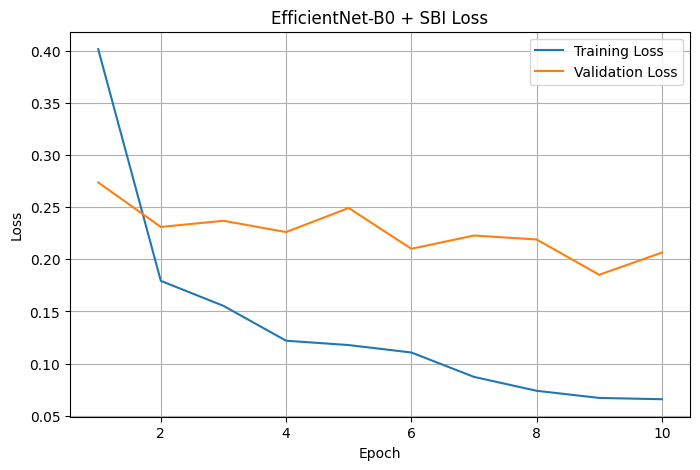

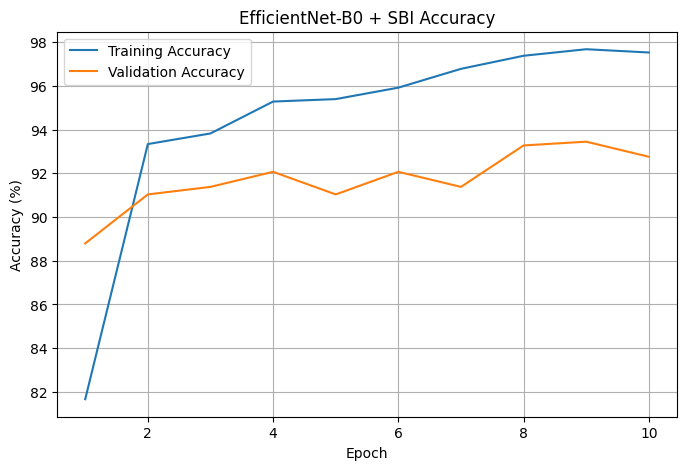

In [7]:
# ============================================================
# E3: EfficientNet-B0 trained with Dynamic SBI
#
# Training:
#   Real frames only
#   Each real frame dynamically produces:
#       real image -> label 0
#       SBI fake   -> label 1
#
# Validation:
#   Deterministic SBI pairs from real validation frames
#
# Model:
#   ImageNet-pretrained EfficientNet-B0
#   Full fine-tuning
#
# Checkpoint:
#   Best validation accuracy is saved
# ============================================================

if RUN_TRAINING:
    import os
    import json
    import time
    import copy
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt

    from torchvision.models import (
        efficientnet_b0,
        EfficientNet_B0_Weights
    )
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score
    )

    # --------------------------------------------------------
    # Paths and device
    # --------------------------------------------------------

    base_path = "/content/drive/MyDrive/deepfake_project"

    model_dir = os.path.join(base_path, "saved_models")
    results_dir = os.path.join(base_path, "results")
    plots_dir = os.path.join(base_path, "plots")

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print("Using device:", device)

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    RANDOM_SEED = 42

    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    # --------------------------------------------------------
    # Training configuration
    # --------------------------------------------------------

    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4

    model_path = os.path.join(
        model_dir,
        CHECKPOINT_NAME
    )

    results_path = os.path.join(
        results_dir,
        RESULTS_NAME
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    weights = EfficientNet_B0_Weights.DEFAULT

    model = efficientnet_b0(weights=weights)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    model = model.to(device)

    # Full fine-tuning:
    # all EfficientNet parameters remain trainable.
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )

    # --------------------------------------------------------
    # Loss and optimiser
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Reduce the learning rate when validation accuracy plateaus.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    # --------------------------------------------------------
    # Metric helper
    # --------------------------------------------------------

    def calculate_metrics(
        labels,
        predictions,
        probabilities
    ):
        accuracy = accuracy_score(
            labels,
            predictions
        ) * 100

        precision = precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        recall = recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        try:
            auc = roc_auc_score(
                labels,
                probabilities
            )
        except ValueError:
            auc = None

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": auc
        }

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_roc_auc": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": [],
        "learning_rate": []
    }

    best_val_accuracy = 0.0
    best_val_auc = 0.0
    best_epoch = 0

    training_start = time.time()

    # --------------------------------------------------------
    # Training loop
    # --------------------------------------------------------

    for epoch in range(NUM_EPOCHS):

        epoch_start = time.time()

        # ====================================================
        # Training
        # ====================================================

        model.train()

        running_train_loss = 0.0
        train_labels = []
        train_predictions = []
        train_probabilities = []

        for batch_index, batch in enumerate(
            train_sbi_loader
        ):
            images = batch["images"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

            probabilities = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            train_labels.extend(
                labels.detach().cpu().numpy()
            )

            train_predictions.extend(
                predictions.detach().cpu().numpy()
            )

            train_probabilities.extend(
                probabilities.detach().cpu().numpy()
            )

            if batch_index % 20 == 0:
                print(
                    f"Epoch {epoch + 1} "
                    f"Batch {batch_index}/"
                    f"{len(train_sbi_loader)} "
                    f"Loss: {loss.item():.4f}"
                )

        average_train_loss = (
            running_train_loss
            / len(train_sbi_loader)
        )

        train_metrics = calculate_metrics(
            train_labels,
            train_predictions,
            train_probabilities
        )

        # ====================================================
        # Validation
        # ====================================================

        model.eval()

        running_val_loss = 0.0
        val_labels = []
        val_predictions = []
        val_probabilities = []

        with torch.no_grad():

            for batch in val_sbi_loader:
                images = batch["images"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["labels"].to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += loss.item()

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )[:, 1]

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_labels.extend(
                    labels.detach().cpu().numpy()
                )

                val_predictions.extend(
                    predictions.detach().cpu().numpy()
                )

                val_probabilities.extend(
                    probabilities.detach().cpu().numpy()
                )

        average_val_loss = (
            running_val_loss
            / len(val_sbi_loader)
        )

        val_metrics = calculate_metrics(
            val_labels,
            val_predictions,
            val_probabilities
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        scheduler.step(
            val_metrics["accuracy"]
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            average_train_loss
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["train_roc_auc"].append(
            train_metrics["roc_auc"]
        )

        history["val_loss"].append(
            average_val_loss
        )

        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )

        history["val_precision"].append(
            val_metrics["precision"]
        )

        history["val_recall"].append(
            val_metrics["recall"]
        )

        history["val_f1"].append(
            val_metrics["f1"]
        )

        history["val_roc_auc"].append(
            val_metrics["roc_auc"]
        )

        history["learning_rate"].append(
            current_learning_rate
        )

        epoch_time = (
            time.time() - epoch_start
        )

        print()
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}]"
        )

        print(
            f"Train Loss: {average_train_loss:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.2f}% | "
            f"Train F1: "
            f"{train_metrics['f1']:.2f}%"
        )

        print(
            f"Val Loss: {average_val_loss:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.2f}% | "
            f"Val Precision: "
            f"{val_metrics['precision']:.2f}% | "
            f"Val Recall: "
            f"{val_metrics['recall']:.2f}% | "
            f"Val F1: "
            f"{val_metrics['f1']:.2f}% | "
            f"Val AUC: "
            f"{val_metrics['roc_auc']:.4f}"
        )

        print(
            f"Learning rate: "
            f"{current_learning_rate:.8f}"
        )

        print(
            f"Epoch time: "
            f"{epoch_time / 60:.2f} minutes"
        )

        # ----------------------------------------------------
        # Save best checkpoint
        # ----------------------------------------------------

        if (
            val_metrics["accuracy"]
            > best_val_accuracy
        ):
            best_val_accuracy = (
                val_metrics["accuracy"]
            )

            best_val_auc = (
                val_metrics["roc_auc"]
                if val_metrics["roc_auc"]
                is not None
                else 0.0
            )

            best_epoch = epoch + 1

            checkpoint = {
                "model_name":
                    "EfficientNet-B0 + Dynamic SBI",
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "epoch":
                    best_epoch,
                "best_val_accuracy":
                    best_val_accuracy,
                "best_val_auc":
                    best_val_auc,
                "learning_rate":
                    LEARNING_RATE,
                "weight_decay":
                    WEIGHT_DECAY,
                "classes": [
                    "real",
                    "fake"
                ]
            }

            torch.save(
                checkpoint,
                model_path
            )

            print(
                "*** Best SBI model updated "
                f"at Epoch {best_epoch} | "
                f"Val Accuracy: "
                f"{best_val_accuracy:.2f}% | "
                f"Val AUC: "
                f"{best_val_auc:.4f} ***"
            )

        print("-" * 70)

    # --------------------------------------------------------
    # Training complete
    # --------------------------------------------------------

    total_training_time = (
        time.time() - training_start
    )

    results = {
        "experiment": "E3a",
        "model":
            "EfficientNet-B0 + Adapted Dynamic SBI",
        "backbone":
            "EfficientNet-B0",
        "pretrained_on":
            "ImageNet",
        "fine_tuning":
            True,
        "backbone_frozen":
            False,
        "training_source":
            "Real FF++ frames only",
        "synthetic_fake_generation":
            "Adapted Dynamic Self-Blended Images",
        "label_mapping": {"real": 0, "fake": 1},
        "validation_type": "deterministic real/SBI pairs",
        "split_unit": "source_video",
        "seed": RANDOM_SEED,
        "epochs":
            NUM_EPOCHS,
        "source_batch_size":
            SOURCE_BATCH_SIZE,
        "effective_batch_size":
            SOURCE_BATCH_SIZE * 2,
        "learning_rate":
            LEARNING_RATE,
        "weight_decay":
            WEIGHT_DECAY,
        "optimizer":
            "Adam",
        "loss":
            "CrossEntropyLoss",
        "best_epoch":
            best_epoch,
        "best_val_accuracy":
            best_val_accuracy,
        "best_val_auc":
            best_val_auc,
        "final_train_loss":
            history["train_loss"][-1],
        "final_val_loss":
            history["val_loss"][-1],
        "total_training_time_minutes":
            round(
                total_training_time / 60,
                2
            ),
        "model_path":
            model_path,
        "history":
            history
    }

    with open(
        results_path,
        "w"
    ) as file:
        json.dump(
            results,
            file,
            indent=4
        )

    print()
    print("Training completed.")
    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.2f}%"
    )
    print(
        f"Best Validation AUC: "
        f"{best_val_auc:.4f}"
    )
    print(
        f"Best Epoch: {best_epoch}"
    )
    print(
        f"Total training time: "
        f"{total_training_time / 60:.2f} minutes"
    )
    print(
        "Best model saved to:",
        model_path
    )
    print(
        "Training results saved to:",
        results_path
    )

    # --------------------------------------------------------
    # Training loss plot
    # --------------------------------------------------------

    epochs = range(
        1,
        NUM_EPOCHS + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        "EfficientNet-B0 + SBI Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_plot_path = os.path.join(
        plots_dir,
        LOSS_PLOT_NAME
    )

    plt.savefig(
        loss_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Accuracy plot
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        "EfficientNet-B0 + SBI Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    accuracy_plot_path = os.path.join(
        plots_dir,
        ACCURACY_PLOT_NAME
    )

    plt.savefig(
        accuracy_plot_path,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "SBI EfficientNet training skipped. "
        "Set RUN_TRAINING = True."
    )

## 7. Next notebook

Use `04f_E3a_FFPP_Evaluation.ipynb` to load `efficientnet_b0_sbi_best.pth` and evaluate it on genuine FaceForensics++ real and manipulated test frames.

Do not generate SBI samples during final testing, and do not use the test set to tune the threshold or choose a checkpoint.